In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
x = np.loadtxt('test.csv',delimiter=',',skiprows=1)
x_train = np.zeros(x.shape[0])
y_train = np.zeros(x.shape[0])
for i in range(x.shape[0]):
    x_train[i] = x[i][0]
    y_train[i] = x[i][1]

In [10]:
def cost_function_compute(x,y,w,b):
    m = x.shape[0]
    J_wb_temp = np.zeros(m)
    for i in range(m):
        J_wb_temp[i] += ( w*x[i] + b - y[i] )**2
    J_wb = 1/2*np.mean(J_wb_temp)
    return J_wb

In [18]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        dj_dw += (w*x[i]+b - y[i])*x[i]
        dj_db += (w*x[i]+b - y[i])
    dj_dw = dj_dw/m
    dj_db = dj_db/m
    return dj_dw, dj_db

In [19]:
def gradient_descent(x, y, w_ini, b_ini, alpha, iters ,cost_function_compute, compute_gradient):
    w = w_ini
    b = b_ini
    J_history = []
    p_history = []
    for i in range(iters):
        dj_dw, dj_db = compute_gradient(x,y,w,b)

        b=b-alpha*dj_db
        w=w-alpha*dj_dw

        if i<100000:
            J_history.append(cost_function_compute(x,y,w,b))
            p_history.append([w,b])
        if i% (iters/10) == 0:
            print(f"Iteration {i}: Cost {J_history[-1]} ",
                  f"dj_dw: {dj_dw}, dj_db: {dj_db}  ",
                  f"w: {w}, b: {b}")

    return w, b, J_history, p_history

In [33]:
w_ini = 0
b_ini = 0
iterations = 10000
tmp_alpha = 0.00055
w_final, b_final, J_hist, p_hist = gradient_descent(x_train, y_train, w_ini, b_ini, tmp_alpha, iterations, cost_function_compute,compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration 0: Cost 1320.613664573332  dj_dw: -3429.609178052974, dj_db: -51.20505109827671   w: 1.886285047929136, b: 0.028162778104052193
Iteration 1000: Cost 4.602959998893056  dj_dw: -0.001488923720424964, dj_db: 0.09950461868770674   w: 1.0080753562470952, b: -0.04345569416926154
Iteration 2000: Cost 4.598168294361918  dj_dw: -0.0013063618663318266, dj_db: 0.0873040289551511   w: 1.0088429153712455, b: -0.09475159133203415
Iteration 3000: Cost 4.594479604658917  dj_dw: -0.0011461845265168336, dj_db: 0.07659939380019706   w: 1.009516361537699, b: -0.1397579292311079
Iteration 4000: Cost 4.591640023955094  dj_dw: -0.0010056470580575667, dj_db: 0.06720728929443905   w: 1.010107234246837, b: -0.17924589148777811
Iteration 5000: Cost 4.589454093659313  dj_dw: -0.0008823413536593231, dj_db: 0.058966781722670544   w: 1.0106256581028117, b: -0.21389210435408432
Iteration 6000: Cost 4.587771348297795  dj_dw: -0.0007741545681293852, dj_db: 0.05173666998376005   w: 1.0110805162986418, b: -0.24

In [42]:
def plot_contour_gradient_descent(x, y, w_history, b_history):
    w_vals = np.linspace(
        min(w_history) - 100,
        max(w_history) + 100,
        200
    )
    b_vals = np.linspace(
        min(b_history) - 100,
        max(b_history) + 100,
        200
    )
    W, B = np.meshgrid(w_vals, b_vals)
    J = np.zeros(W.shape)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):

            J[i, j] = cost_function_compute(
                x,
                y,
                W[i, j],
                B[i, j]
            )
    plt.figure(figsize=(10, 7))
    contours = plt.contour(
        W,
        B,
        J,
        levels=40
    )
    plt.clabel(
        contours,
        inline=True,
        fontsize=8
    )
    w_history = np.array(w_history)
    b_history = np.array(b_history)
    plt.plot(
        w_history,
        b_history,
        'r.-',
        label='Gradient Descent'
    )
    plt.scatter(
        w_history[0],
        b_history[0],
        color='black',
        s=80,
        label='Start'
    )
    plt.scatter(
        w_history[-1],
        b_history[-1],
        color='red',
        s=80,
        label='Final'
    )
    plt.xlabel('w')
    plt.ylabel('b')
    plt.title('Gradient Descent on Cost Function')
    plt.legend()
    plt.grid()
    plt.show()

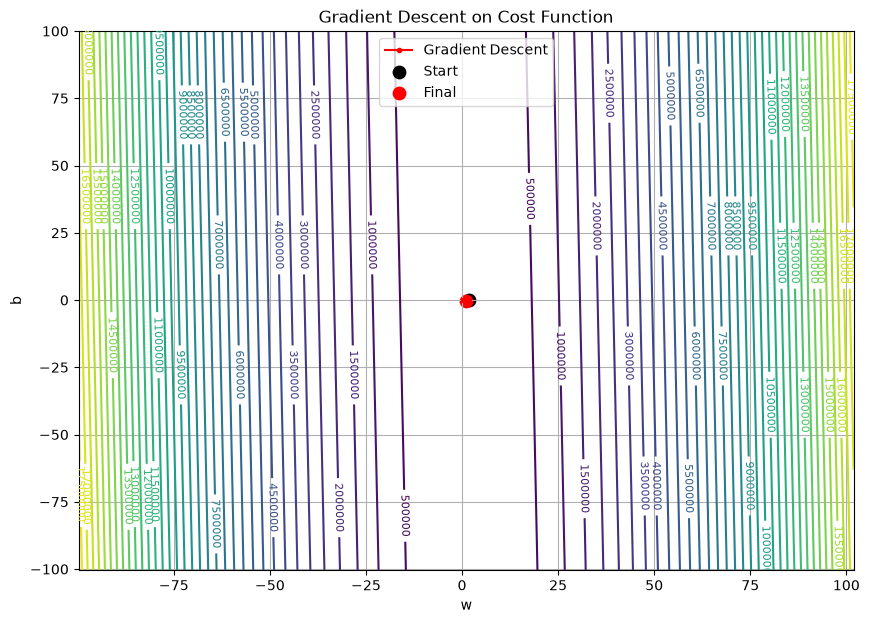

In [43]:
plot_contour_gradient_descent(
    x_train,
    y_train,
    [pair[0] for pair in p_hist],
    [pair[1] for pair in p_hist]
)